### Lab IV: Linear Models
### Answer all three sets of questions

#### Turn in one python file for the three computation questions and one text file for Q0

**Q0.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear when the coeifficients are linear. his means the coefficients are multiplied by variables and added together, and are not multiplied by each other or raised to powers.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed.

You interpert the difference in the predicted outcome between that category and the reference category, assuming all other variables stay consistent.

3. Can linear regression be used for classification? Explain why, or why not.

Linear regression cannot be used for classification because it predicts continuous numerical and classification requires discrete categories. 

4. If you have a high accuracy on training but low on testing, what might be the problem? It also might be you see a pattern in the residuals. 

If you have a high accauarcy on training but on testing the problem could be overfitting. There is likely not enough training data, too many features being analyzed or the model is complex. 

5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$?

You can incorperate nonlinear relationships between varaibles and features by including expert knowledge which can be directly used by a simple linear model, or using a “kernel” to have a locally-based decision function instead of a global linear decision function.

6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

The intercept is the predicted value of the target variable when all predictor variables are equal to zero. A slope coefficient is the expected change in the target variable for a 1 unit increase in the predictor variable, while other variables stay consistent. The coefficient dummy variable is the difference predicted value between that category and the reference category.

**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

housing_data = pd.read_csv('Q1_clean.csv')
housing_data.info() 
# allows us to learn the shape of object types of our data

<class 'pandas.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 22153 non-null  int64  
 1   Review Scores Rating  22153 non-null  float64
 2   Neighbourhood         22153 non-null  str    
 3   Property Type         22153 non-null  str    
 4   Room Type             22153 non-null  str    
dtypes: float64(1), int64(1), str(3)
memory usage: 865.5 KB


In [86]:
housing_data.head(5)
# prints the first 5 rows of our data to get a better understanding of what it looks like

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96,Manhattan,Apartment,Private room
1,149,100,Brooklyn,Apartment,Entire home/apt
2,250,100,Manhattan,Apartment,Entire home/apt
3,90,94,Brooklyn,Apartment,Private room
4,270,90,Manhattan,Apartment,Entire home/apt


In [87]:
housing_data.describe()
# gives us a statistical summary of our data, including count, mean, std, min, etc.

,Price,Review Scores Rating
count,"22,153","22,153"
mean,155,92
std,149,9
min,10,20
25%,85,89
50%,125,94
75%,190,100
max,"10,000",100


In [88]:
housing_data.columns = housing_data.columns.str.strip()
# removes any leading or trailing whitespace from the column names to ensure they are clean and consistent

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.

In [89]:
housing_data.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean().sort_values(by='Price', ascending=False)
# shows us the average price and review score for each neighborhood


,Price,Review Scores Rating
Neighbourhood,,
Manhattan,184,92
Staten Island,146,91
Brooklyn,128,92
Queens,97,92
Bronx,75,92


The most expensive borough is Manhattan at the price of 183.664286.

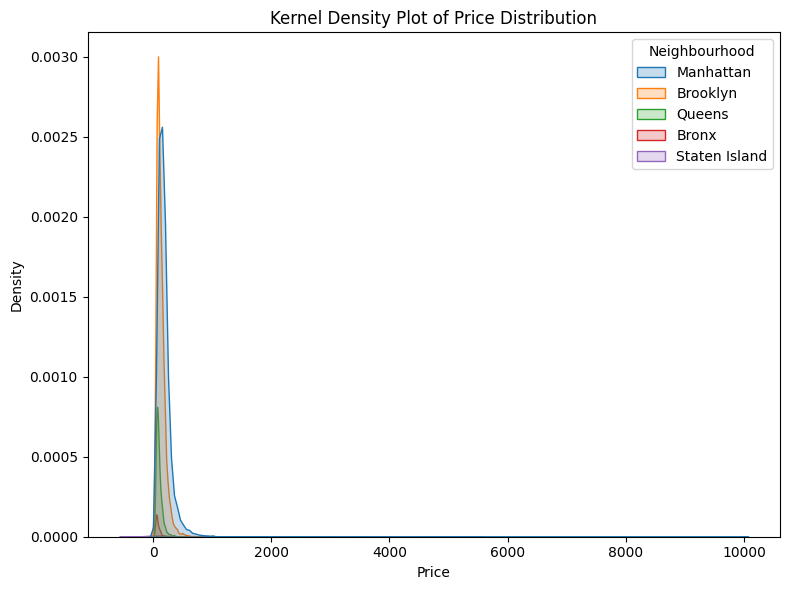

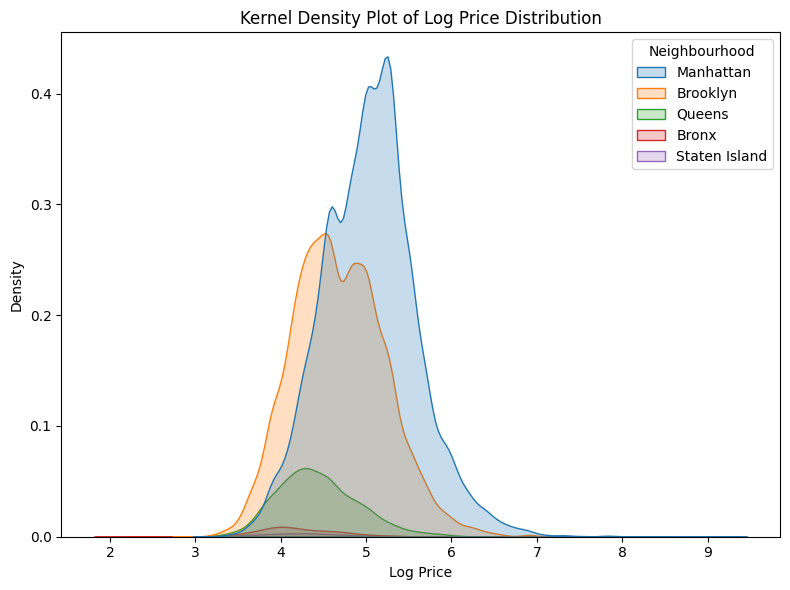

In [90]:
# kernel density plot of price distribution
plt.figure(figsize=(8, 6))
sns.kdeplot(housing_data, x='Price', hue='Neighbourhood', fill=True)
# hue is the grouping variable, it tells seaborn to create separate density plots for each neighborhood and the color specifies each density plots
plt.title('Kernel Density Plot of Price Distribution')
plt.xlabel('Price')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

housing_data['log_price'] = np.log(housing_data['Price'])


plt.figure(figsize=(8, 6))
sns.kdeplot(housing_data, x='log_price', hue='Neighbourhood', fill=True)
# hue is the grouping variable, it tells seaborn to create separate density plots for each neighborhood and the color specifies each density plots
plt.title('Kernel Density Plot of Log Price Distribution')
plt.xlabel('Log Price')
plt.ylabel('Density')  

plt.tight_layout()
plt.show()

2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

In [93]:
housing_data_dummies = pd.get_dummies(housing_data, columns=['Neighbourhood'], drop_first=False, dtype='float')
# drop_first=False because there is an intercept term in the linear regression model

# housing_data_dummies.head(6), showed me the names of the columns after creating dummies

X = housing_data_dummies[['Neighbourhood_Bronx','Neighbourhood_Brooklyn','Neighbourhood_Manhattan','Neighbourhood_Queens','Neighbourhood_Staten Island']]
Y = housing_data_dummies['Price']

from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=False)
model.fit(X, Y)
# the fit_intercept=False argument is used to indicate that we do not want to include an intercept term in our linear regression model. This is because we have already included dummy variables for each neighborhood, which will capture the effect of each neighborhood on the price without needing an additional intercept term.

print(model.coef_)
# the underscore in model.coef_ is used to access the coefficients of the linear regression model. The coefficients represent the estimated effect of each independent variable (in this case, each neighborhood) on the dependent variable (price). Each coefficient indicates how much the price is expected to change for a one-unit change in the corresponding neighborhood variable, holding all other variables constant.
print(X.columns.tolist())

[ 75.2764977  127.74737834 183.66428632  96.8572327  146.16666667]
['Neighbourhood_Bronx', 'Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island']


The pattern I see is that the prices for each neighbourhood match the ones from when we found the average prices and scores by neighbourhoods. The coefficients in a regression of a continous variable on one categorical variable is representing the average price for that neighbourhood.

3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

In [94]:
housing_data_dummies = pd.get_dummies(housing_data, columns=['Neighbourhood'], drop_first=True, dtype='float')
# drop_first=True to avoid the dummy variable trap

X = housing_data_dummies[['Neighbourhood_Brooklyn','Neighbourhood_Manhattan','Neighbourhood_Queens','Neighbourhood_Staten Island']]
Y = housing_data_dummies['Price']

from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True)
model.fit(X, Y)
# the fit_intercept=False argument is used to indicate that we do not want to include an intercept term in our linear regression model. This is because we have already included dummy variables for each neighborhood, which will capture the effect of each neighborhood on the price without needing an additional intercept term.

print(model.coef_)
# the underscore in model.coef_ is used to access the coefficients of the linear regression model. The coefficients represent the estimated effect of each independent variable (in this case, each neighborhood) on the dependent variable (price). Each coefficient indicates how much the price is expected to change for a one-unit change in the corresponding neighborhood variable, holding all other variables constant.
print(X.columns.tolist())

[ 52.47088065 108.38778863  21.58073501  70.89016897]
['Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island']


I created the dummies the same way, except this time I made the drop_first=True so that we can avoid the dummy variable trap, which drops the Bronx as the reference category. The intercept is the predicted value of the target variable when all predictor variables are equal to zero. The coefficients are lower than before because they now show the difference in average price compared to the Bronx. You can add the intercepts to each coefficient to get back the coefficients in part 2.

4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [99]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
 
housing_data_dummies = pd.get_dummies(housing_data, columns=['Neighbourhood'], drop_first=True, dtype='float')

X = housing_data_dummies[['Review Scores Rating', 'Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island']]
Y = housing_data_dummies['Price']

model = linear_model.LinearRegression()
# linear regression model is trained on the training data (X_train and Y_train) and then used to make predictions on the test data (X_test)
model.fit(X_train, Y_train)
predicted = model.predict(X_test)
# the predicted variable contains the predicted prices for the test data based on the linear regression model

print('R2 Score (Testing):', r2_score(Y_test, predicted))
# the r2_score function is used to evaluate the performance of the linear regression model
print(' Root Mean Squared Error (Testing):', np.sqrt(mean_squared_error(Y_test, predicted)))
# prints the mean squared error of the predictions, which is a measure of how well the model's predictions match the actual values in the test set

print(model.coef_)
# the underscore in model.coef_ is used to access the coefficients of the linear regression model
print(X.columns.tolist())
# the coefficients represent the estimated effect of each independent variable 

R2 Score (Testing): 0.08230721172544131
 Root Mean Squared Error (Testing): 106.28986886521714
[  1.02750916  52.04910635 109.3336238   21.62439234  88.97970347]
['Review Scores Rating', 'Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island']


The r2 for the test set is 0.08230721172544131. The RMSE for the test set is 106.28986886521714. The coefficient of `Review Scores Rating` is 1.02750916. The most expensive kind of property you can rent is in Manhattan because it is $109.3336238 more than the Bronx, the reference category.

5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [101]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
 
housing_data_dummies = pd.get_dummies(housing_data, columns=['Neighbourhood', 'Property Type'], drop_first=True, dtype='float')
# housing_data_dummies.head(6) to see the property type columns

X = housing_data_dummies[[ 'Review Scores Rating', 'Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island', 'Property Type_Bed & Breakfast', 
                        'Property Type_Boat', 'Property Type_Bungalow', 'Property Type_Cabin', 'Property Type_Camper/RV', 'Property Type_Castle', 'Property Type_Chalet', 'Property Type_Condominium', 
                        'Property Type_Dorm', 'Property Type_House', 'Property Type_Hut', 'Property Type_Lighthouse', 'Property Type_Loft', 'Property Type_Other', 'Property Type_Townhouse', 'Property Type_Treehouse'
                        ,'Property Type_Villa']]

Y = housing_data_dummies['Price']

model = linear_model.LinearRegression()
# linear regression model is trained on the training data (X_train and Y_train) and then used to make predictions on the test data (X_test)
model.fit(X_train, Y_train)
predicted = model.predict(X_test)
# the predicted variable contains the predicted prices for the test data based on the linear regression model

print('R2 Score (Testing):', r2_score(Y_test, predicted))
# the r2_score function is used to evaluate the performance of the linear regression model
print('Root Mean Squared Error (Testing):', np.sqrt(mean_squared_error(Y_test, predicted)))
# prints the mean squared error of the predictions, which is a measure of how well the model's predictions match the actual values in the test set

print(model.coef_)
# the underscore in model.coef_ is used to access the coefficients of the linear regression model
print(X.columns.tolist())
# the coefficients represent the estimated effect of each independent variable
print('Most expensive property type:',str(X.columns[12]) + ": " + str(model.coef_[12]))

R2 Score (Testing): 0.08534318021973553
Root Mean Squared Error (Testing): 106.11390582635056
[   1.01681137   60.47317693  123.42997013   28.38299784   82.3286457
  -30.01664281   81.36450192   28.57319701   35.16739045  -15.56782596
  -41.08304917  -28.1094446   102.5068739   -49.65442857   36.09262338
 -134.98218096  -89.12625597   67.01091959   -7.44734694   86.58686941
  -76.87290706   34.58555853]
['Review Scores Rating', 'Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island', 'Property Type_Bed & Breakfast', 'Property Type_Boat', 'Property Type_Bungalow', 'Property Type_Cabin', 'Property Type_Camper/RV', 'Property Type_Castle', 'Property Type_Chalet', 'Property Type_Condominium', 'Property Type_Dorm', 'Property Type_House', 'Property Type_Hut', 'Property Type_Lighthouse', 'Property Type_Loft', 'Property Type_Other', 'Property Type_Townhouse', 'Property Type_Treehouse', 'Property Type_Villa']
Most expensive property type: Proper

The r2 for the test set is 0.08534318021973553. The RMSE for the test set is 106.11390582635056. The coefficient of `Review Scores Rating` is 1.01681137. The most expensive kind of property you can rent is a condominium it is $102.50687390010275 more than the bronx (reference category).

6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.

The coefficent for Review Scores Rating Type improved the model slightly. It went from r2=0.08230721172544131 to r2=0.08534318021973553 and the RMSE also went up slightly from 106.28986886521714 to 106.11390582635056. This says that Property Type does not add much explanatory power beyond Neighbourhood alone.

7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  

In [71]:
cars_hw = pd.read_csv('cars_hw.csv')

cars_hw.info()

<class 'pandas.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         976 non-null    int64
 1   Make               976 non-null    str  
 2   Make_Year          976 non-null    int64
 3   Color              976 non-null    str  
 4   Body_Type          976 non-null    str  
 5   Mileage_Run        976 non-null    int64
 6   No_of_Owners       976 non-null    str  
 7   Seating_Capacity   976 non-null    int64
 8   Fuel_Type          976 non-null    str  
 9   Transmission       976 non-null    str  
 10  Transmission_Type  976 non-null    str  
 11  Price              976 non-null    int64
dtypes: int64(5), str(7)
memory usage: 91.6 KB


In [72]:
cars_hw.head(5)
# prints the first 5 rows of our data to get a better understanding of what it looks like

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [73]:
cars_hw.describe()
# gives us a statistical summary of our data, including count, mean, std, min, etc.

,Unnamed: 0,Make_Year,Mileage_Run,Seating_Capacity,Price
count,976,976,976,976,976
mean,488,"2,017","41,571",5,"741,019"
std,282,3,"24,391",0,"367,323"
min,1,"2,011","1,117",4,"188,000"
25%,245,"2,015","22,677",5,"475,750"
50%,488,"2,017","37,570",5,"666,500"
75%,732,"2,019","57,421",5,"883,000"
max,976,"2,022","99,495",8,"2,941,000"


In [74]:
cars_hw['Transmission'] = cars_hw['Transmission'].str.extract('(\d+)').astype(float)
# takes away the text and leaves the number 

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_64012/402869715.py:1: SyntaxWarning: invalid escape sequence '\d'
  cars_hw['Transmission'] = cars_hw['Transmission'].str.extract('(\d+)').astype(float)


In [75]:
cars_hw['No_of_Owners'] = cars_hw['No_of_Owners'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_64012/890287684.py:1: SyntaxWarning: invalid escape sequence '\d'
  cars_hw['No_of_Owners'] = cars_hw['No_of_Owners'].str.extract('(\d+)').astype(float)


2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

In [76]:
cars_hw.groupby('Make')[['Price']].describe().sort_values(by=('Price', 'mean'), ascending=False)
# shows us the average price and review score for each neighborhood 

Price                                                    \
              count      mean       std       min       25%       50%   
Make                                                                    
MG Motors        35 1,869,457   121,661 1,589,000 1,786,500 1,848,000   
Kia               8 1,614,750   119,057 1,369,000 1,579,000 1,628,500   
Jeep              4 1,499,500   152,513 1,290,000 1,447,500 1,529,500   
Skoda             5 1,136,000 1,070,175   436,000   466,000   538,000   
Mahindra         18 1,100,167   175,549   796,000 1,037,000 1,094,500   
Tata             23 1,055,217   557,831   188,000   779,500   869,000   
Nissan            4   884,250   289,560   475,000   782,500   978,000   
Toyota           50   800,340   246,690   368,000   526,250   894,000   
Honda            73   798,973   266,509   316,000   581,000   785,000   
Ford             52   721,173   140,928   290,000   635,000   707,500   
Hyundai         305   691,892   279,160   248,000   485,000   638,000   
Renault          68   662,574   214,827   287,000   475,000   644,000   
Volkswagen       29   605,828   119,831   402,000   542,000   607,000   
Maruti Suzuki   293   588,785   216,020   237,000   411,000   527,000   
Chevrolet         6   453,500   246,606   267,000   288,500   345,500   
Datsun            3   289,667    10,504   279,000   284,500   290,000   

                                   
                    75%       max  
Make                               
MG Motors     1,978,000 2,019,000  
Kia           1,705,750 1,741,000  
Jeep          1,581,500 1,649,000  
Skoda         1,299,000 2,941,000  
Mahindra      1,157,000 1,465,000  
Tata          1,552,000 2,100,000  
Nissan        1,079,750 1,106,000  
Toyota        1,023,000 1,092,000  
Honda           915,000 1,537,000  
Ford            787,000 1,066,000  
Hyundai         837,000 1,742,000  
Renault         801,000 1,164,000  
Volkswagen      699,000   790,000  
Maruti Suzuki   764,000 1,163,000  
Chevrolet       537,500   892,000  
Datsun          295,000   300,000

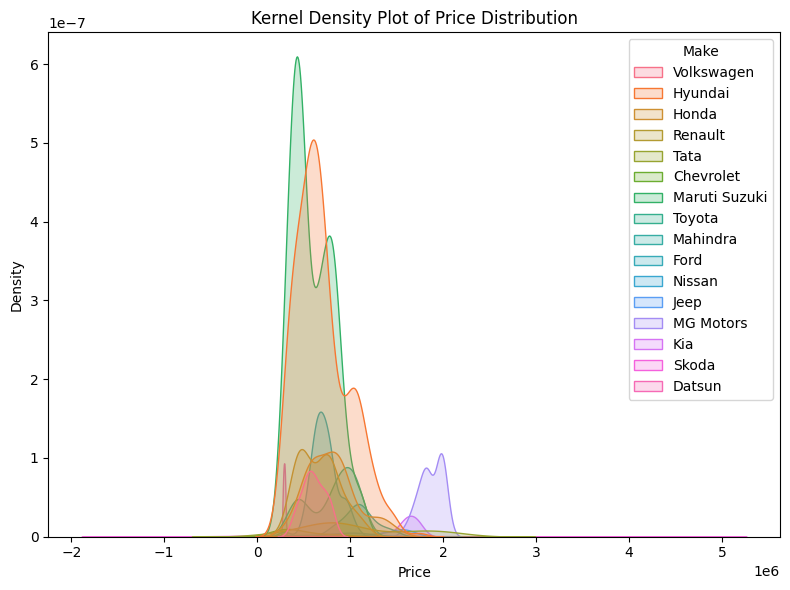

In [77]:
# kernel density plot of price distribution
plt.figure(figsize=(8, 6))
sns.kdeplot(cars_hw, x='Price', hue='Make', fill=True)
# hue is the grouping variable, it tells seaborn to create separate density plots for each neighborhood and the color specifies each density plots
plt.title('Kernel Density Plot of Price Distribution')
plt.xlabel('Price')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

The most expensive car brands are MG Motors, Kia, Jeep, Skoda, Mahindra, and Tata. The models are more expensive as the graph skews right. 

 3. Split the data into an 80% training set and a 20% testing set.

In [78]:
cars_hw_dummies = pd.get_dummies(cars_hw, columns=['Make'], drop_first=True, dtype='float')

# cars_hw_dummies.head(5), to see the names of the columns after creating dummies

X = cars_hw_dummies[['Make_Datsun', 'Make_Ford', 'Make_Honda', 'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors', 'Make_Mahindra', 'Make_Maruti Suzuki',
                     'Make_Nissan', 'Make_Renault', 'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen']]
Y = cars_hw_dummies['Price']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)

4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

In [ ]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

model = linear_model.LinearRegression()
# linear regression model is trained on the training data (X_train and Y_train) and then used to make predictions on the test data (X_test)
model.fit(X_train, Y_train)
predicted = model.predict(X_test)
# the predicted variable contains the predicted prices for the test data based on the linear regression model

print('R2 Score (Training):', r2_score(Y_train, model.predict(X_train)))
# the r2_score function is used to evaluate the performance of the linear regression model
print('Root Mean Squared Error (Training):', np.sqrt(mean_squared_error(Y_train, model.predict(X_train))))
# prints the mean squared error of the predictions, which is a measure of how well the model's predictions match the actual values in the test set

print('R2 Score (Testing):', r2_score(Y_test, predicted))
# the r2_score function is used to evaluate the performance of the linear regression model
print('Root Mean Squared Error (Testing):', np.sqrt(mean_squared_error(Y_test, predicted)))
# prints the mean squared error of the predictions, which is a measure of how well the model's predictions match the actual values in the test set

print(model.coef_)
# the underscore in model.coef_ is used to access the coefficients of the linear regression model
print(X.columns.tolist())
# the coefficients represent the estimated effect of each independent variable 

R2 Score (Training): 0.056199236739973624
Root Mean Squared Error (Training): 152.41399370044306
R2 Score (Testing): 0.08534318021973553
Root Mean Squared Error (Testing): 106.11390582635056
[   1.01681137   60.47317693  123.42997013   28.38299784   82.3286457
  -30.01664281   81.36450192   28.57319701   35.16739045  -15.56782596
  -41.08304917  -28.1094446   102.5068739   -49.65442857   36.09262338
 -134.98218096  -89.12625597   67.01091959   -7.44734694   86.58686941
  -76.87290706   34.58555853]
['Review Scores Rating', 'Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island', 'Property Type_Bed & Breakfast', 'Property Type_Boat', 'Property Type_Bungalow', 'Property Type_Cabin', 'Property Type_Camper/RV', 'Property Type_Castle', 'Property Type_Chalet', 'Property Type_Condominium', 'Property Type_Dorm', 'Property Type_House', 'Property Type_Hut', 'Property Type_Lighthouse', 'Property Type_Loft', 'Property Type_Other', 'Property Type_T

In [118]:
cars_cat = pd.get_dummies(cars_hw, columns=['Make', 'Color', 'Body_Type', 'Fuel_Type', 'Transmission_Type'], drop_first=True, dtype='float')

cat_cols = [col for col in cars_cat.columns if any(col.startswith(c) for c in ['Make_', 'Color_', 'Body_Type_', 'Fuel_Type_', 'Transmission_Type_'])]

X = cars_cat[cat_cols]
Y = cars_cat['Price']

# Must re-split with the new X and Y
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=40)

model2 = linear_model.LinearRegression()
model2.fit(X_train, Y_train)
predicted2 = model2.predict(X_test)

print('R2 Score (Testing):', r2_score(Y_test, predicted2))
print('RMSE (Testing):', np.sqrt(mean_squared_error(Y_test, predicted2)))
print(model2.coef_)
print(X.columns.tolist())

R2 Score (Testing): 0.7909167116992457
RMSE (Testing): 145350.47693280943
[  49953.26835468  -35337.03712854    6740.50313855  206035.93145351
  195287.76064974  544210.88316283  737855.44694103  828096.44560058
  184057.55074946  119947.28542101    9498.9548007   -19607.4979443
  602892.05869685  304346.69879828  244319.33719756  141364.12698202
  293347.74749985  159029.2844954    63804.42871451  163553.8930649
  149857.64130813  290664.4245269   113335.60951072  173695.72618405
  175907.79042238   70407.0265695   162011.90816067  139930.71669425
  158172.84806978   88292.97417911  -42725.78048529   56386.09419972
  141990.58347798  287182.12369204 -173856.86096451 -258998.36772859
  -74586.02684044]
['Make_Year', 'Make_Datsun', 'Make_Ford', 'Make_Honda', 'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors', 'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault', 'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen', 'Color_black', 'Color_blue', 'Color_bronze

In [121]:
num_cols = ['Make_Year', 'Mileage_Run', 'Seating_Capacity', 'Transmission', 'No_of_Owners']

X = cars_cat[num_cols + cat_cols]
Y = cars_cat['Price']

# Drop NaNs since numeric cols may have them
combined = pd.concat([X, Y], axis=1).dropna()
X = combined[num_cols + cat_cols]
Y = combined['Price']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=40)

model3 = linear_model.LinearRegression()
model3.fit(X_train, Y_train)
predicted3 = model3.predict(X_test)

print('R2 Score (Testing):', r2_score(Y_test, predicted3))
print('RMSE (Testing):', np.sqrt(mean_squared_error(Y_test, predicted3)))
print(model3.coef_)
print(X.columns.tolist())

R2 Score (Testing): 0.8546133843315133
RMSE (Testing): 132885.999796718
[ 1.07418510e+04  1.07418510e+04 -5.02423958e-01  1.36735423e+05
  1.14851538e+05 -3.69993837e+04  1.07418510e+04  1.07418510e+04
  7.62229423e+04  7.56049317e+04  2.32901572e+05  2.30421131e+05
  5.52978268e+05  7.02334898e+05  8.79477751e+05 -1.03674097e+04
  1.84967080e+05  1.31551048e+05  2.07239948e+04  5.56668812e+05
  3.43910474e+05  2.81179438e+05  1.92283437e+05  2.10576491e+05
  1.43567852e+05  9.91842890e+04  1.47296207e+05  1.40237062e+05
  2.50251862e+05  1.03963355e+05  2.15688924e+05  1.65473816e+05
  3.61448063e+04  1.37113000e+05  1.16811614e+05  1.23883860e+05
  6.58760747e+04 -9.02817967e+04 -1.86244765e+05  1.14896771e+05
  2.12291191e+05 -1.40237795e+05 -2.29593775e+05 -5.30501739e+04]
['Make_Year', 'Make_Year', 'Mileage_Run', 'Seating_Capacity', 'Transmission', 'No_of_Owners', 'Make_Year', 'Make_Year', 'Make_Datsun', 'Make_Ford', 'Make_Honda', 'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG 

5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

In [122]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

num_cols = ['Make_Year', 'Mileage_Run', 'Seating_Capacity', 'Transmission', 'No_of_Owners']

X = cars_hw[num_cols].dropna()
Y = cars_hw.loc[X.index, 'Price']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=40)

# Try increasing degrees to see how R² and RMSE change
for degree in [1, 2, 3, 4, 5]:
    model = make_pipeline(PolynomialFeatures(degree=degree), linear_model.LinearRegression())
    model.fit(X_train, Y_train)
    predicted = model.predict(X_test)
    r2 = r2_score(Y_test, predicted)
    rmse = np.sqrt(mean_squared_error(Y_test, predicted))
    print(f"Degree {degree}: R² = {r2:.4f}, RMSE = {rmse:.2f}")

Degree 1: R² = 0.4490, RMSE = 258703.55
Degree 2: R² = 0.4679, RMSE = 254225.30
Degree 3: R² = 0.4572, RMSE = 256759.24
Degree 4: R² = 0.4589, RMSE = 256354.48
Degree 5: R² = 0.4634, RMSE = 255296.74


  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.

In [17]:
bmws = pd.read_csv('bmw.csv')
bmws.info() 

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB


2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.

In [123]:
housing_data.head(5)
# prints the first 5 rows of our data to get a better understanding of what it looks like

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type,log_price
0,549,96,Manhattan,Apartment,Private room,6
1,149,100,Brooklyn,Apartment,Entire home/apt,5
2,250,100,Manhattan,Apartment,Entire home/apt,6
3,90,94,Brooklyn,Apartment,Private room,4
4,270,90,Manhattan,Apartment,Entire home/apt,6


In [124]:
housing_data.describe()
# gives us a statistical summary of our data, including count, mean, std, min, etc.

,Price,Review Scores Rating,log_price
count,"22,153","22,153","22,153"
mean,155,92,5
std,149,9,1
min,10,20,2
25%,85,89,4
50%,125,94,5
75%,190,100,5
max,"10,000",100,9


3. Split the sample into an ~80% training set and a ~20% test set.

4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.

5. Which model performed the best, and why?

The model that performed the best was...

6. What did you learn?

I learned that there are many ways to use a linear regression. There ...

### Dummy Variable Trap 


In linear regression with categorical variables you should be careful of the Dummy Variable Trap. 
The Dummy Variable trap is a scenario in which the independent variables are multicollinear - a 
scenario in which two or more variables are highly correlated; in simple terms one variable can 
be predicted from the others. This can produce singularity of a model, meaning your model just won't 
work. Read about it below:

Idea is to use dummy variable encoding with drop_first=True, this will omit one column from each 
category after converting categorical variable into dummy/indicator variables. You WILL NOT lose 
and relevant information by doing that simply because your all point in dataset can fully be 
explained by rest of the features.

Here is complete code on how you can do it for a "jobs" dataset

So you have your X features:

Age, Gender, Job, Classification 

And one numerical features that you are trying to predict:

Wage

First you need to split your initial dataset on input variables and prediction, 
assuming its pandas dataframe it would look like this:

Input variables (your dataset is bit different but whole code remains the same, 
you will put every column from dataset in X, except one that will go to Y. pd.get_dummies 
works without problem like that - it will just convert categorical variables and it won't 
touch numerical):

X = jobs[['Age','Gender','Job','Classification']]

Prediction:

Y = jobs['Wage']

Convert categorical variable into dummy/indicator variables and drop one in each category:

X = pd.get_dummies(data=X, drop_first=True)

So now if you check shape of X (X.shape) with drop_first=True you will see that it has 
4 columns less - one for each of your categorical variables.

You can now continue to use them in your linear model. For scikit-learn implementation it 
could look like this:


In [ ]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
    
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
    
regr = linear_model.LinearRegression() # Do not use fit_intercept = False if you have removed 
1 column after dummy encoding

regr.fit(X_train, Y_train)
predicted = regr.predict(X_test)

### Transformation versus Normalization

Use a **log transformation** when your data is strictly positive and heavily skewed towards larger values (right-skewed), while an **arcsinh transformation** is better suited for data with both positive and negative values, or when you need to handle potential zero values; **normalize** your data when you need to scale all values to a similar range, typically between 0 and 1, and especially when using algorithms sensitive to feature scale, but not necessarily to achieve a **normal distribution**. 
Key points about each transformation: 

    Log transformation: 

    Best for positively skewed data with large variations in magnitude. 

Useful when analyzing relative changes rather than absolute differences. 
Cannot handle negative values. 

Arcsinh transformation:

    Can handle both positive and negative data. 

Effective for data with extreme values on both ends of the spectrum. 
Often used when dealing with proportions or percentages near 0 or 1. 

Normalization: 

    Scales data to a common range, usually between 0 and 1. 

Useful when comparing features with different scales in machine learning algorithms. 
Does not necessarily transform the data distribution to be normal. 
